[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bniko05/sentiment-and-image-classification/blob/main/notebooks/01_imdb_classical_classifiers.ipynb)

# IMDB Sentiment Analysis: Classical Classifiers

Binary bag-of-words features selected by **Information Gain**, classified with **Naive Bayes**, **Random Forest** and **AdaBoost**, with learning curves for each model.

> ⏱️ Runs on a CPU runtime. The Information Gain step takes several minutes.

In [ ]:
import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=None)

print(len(x_train))

word_index = tf.keras.datasets.imdb.get_word_index()
index2word = dict((i + 3, word) for (word, i) in word_index.items())
index2word[0] = '[pad]'
index2word[1] = '[bos]'
index2word[2] = '[oov]'
x_train = np.array([' '.join([index2word[idx] for idx in text]) for text in x_train])
x_test = np.array([' '.join([index2word[idx] for idx in text]) for text in x_test])

25000


In [ ]:
n = 20
k = 50000
m = 8000

words_frequency = {}

for text in x_train:
  tokens = text.split()
  temp_voc = set(tokens)

  for word in temp_voc:
    if word in words_frequency:
      words_frequency[word] += 1
    else:
      words_frequency[word] = 1

sorted_word_frequency = sorted(words_frequency.items(), key=lambda item: item[1])

vocabulary = [item[0] for item in sorted_word_frequency[k : -n]]

In [ ]:
def makeBinaryData(data, vocabulary):
  word_to_index = {word: i for i, word in enumerate(vocabulary)}
  binaryData = np.zeros((len(data), len(vocabulary)), dtype=np.int8)
  for i, review in enumerate(data):
    tokens = review.split()
    for word in tokens:
      if word in word_to_index:
        j = word_to_index[word]
        binaryData[i, j] = 1
  return binaryData

In [ ]:
import math
def IG(class_, feature):
  classes = set(class_)

  Hc = 0
  for c in classes:
    pc = list(class_).count(c)/len(class_)
    Hc += - pc * math.log(pc, 2)
  #print('Overall Entropy:', Hc)
  feature_values = set(feature)

  Hc_feature = 0
  for feat in feature_values:

    #pf --> P(X=x)
    pf = list(feature).count(feat)/len(feature)
    indices = [i for i in range(len(feature)) if feature[i] == feat]
    clasess_of_feat = [class_[i] for i in indices]
    for c in classes:
        #pcf --> P(C=c|X=x)
        pcf = clasess_of_feat.count(c)/len(clasess_of_feat)
        if pcf != 0:
            # - P(X=x) * P(C=c|X=x) * log2(P(C=c|X=x))
            temp_H = - pf * pcf * math.log(pcf, 2)
            #sum for all values of C (class) and X (values of specific feature)
            Hc_feature += temp_H
  ig = Hc - Hc_feature
  return ig

In [ ]:
x_train_full = makeBinaryData(x_train, vocabulary)
word_ig_scores = {}

for i, word in enumerate(vocabulary):

    feature_column = x_train_full[:, i]
    ig_score = IG(list(y_train), list(feature_column))
    word_ig_scores[word] = ig_score

sorted_words_by_ig = sorted(word_ig_scores.items(), key=lambda x: x[1], reverse=True)
vocabulary_ig = [word for word, score in sorted_words_by_ig[:m]]

In [ ]:
x_train_final = makeBinaryData(x_train, vocabulary_ig)
x_test_final = makeBinaryData(x_test, vocabulary_ig)

from sklearn.model_selection import train_test_split
x_train_sub, x_dev, y_train_sub, y_dev = train_test_split(x_train_final, y_train, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(criterion='entropy', n_estimators=500, random_state = 42)
rf.fit(x_train_final, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=42)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf.predict(x_test_final)))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ab = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=250,
    random_state=1)
ab.fit(x_train_final, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=250, random_state=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ab.predict(x_test_final)))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81     12500
           1       0.80      0.84      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train_final, y_train)

MultinomialNB()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, nb.predict(x_test_final)))


              precision    recall  f1-score   support

           0       0.81      0.88      0.85     12500
           1       0.87      0.80      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



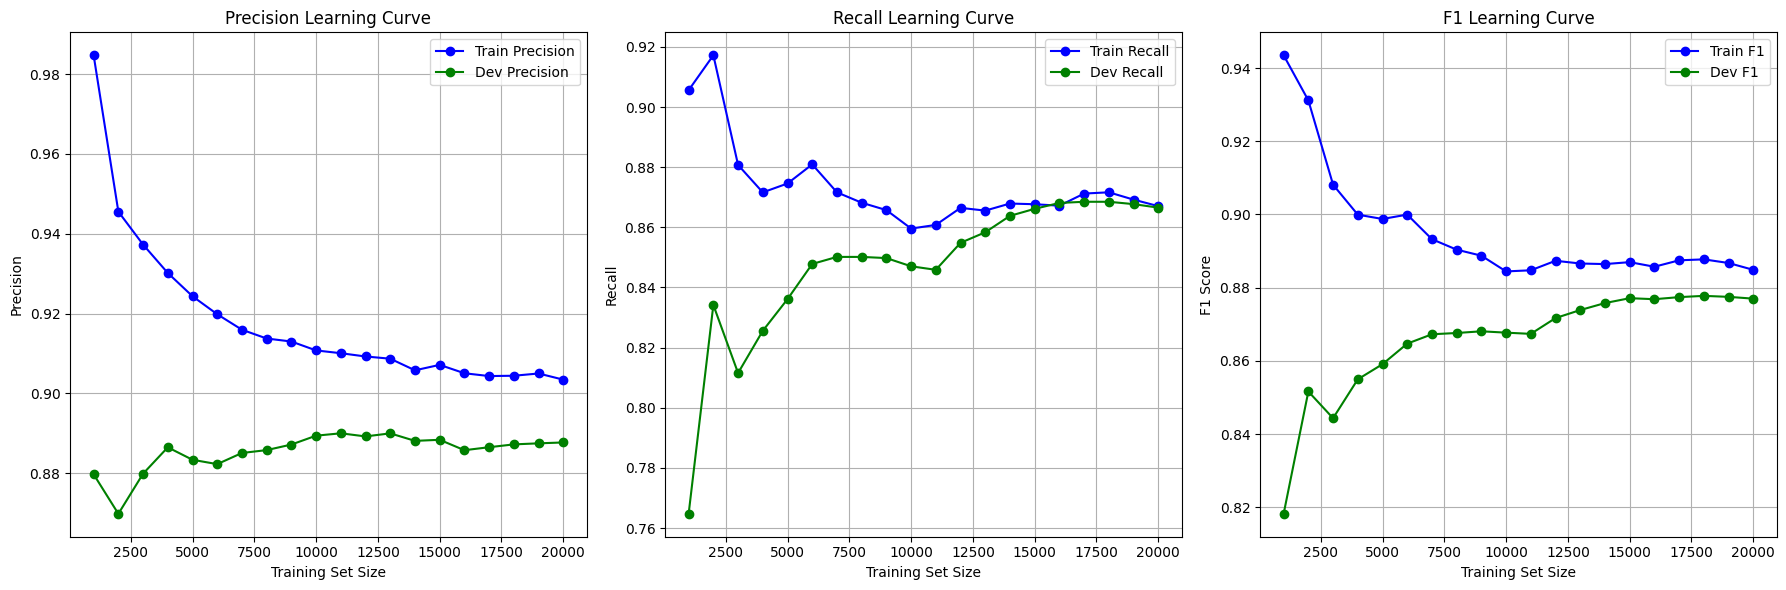

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import BernoulliNB

def NaiveBayes_learning_curves(x_train, y_train, x_val, y_val, x_test, y_test, n_splits):
    split_size = int(len(x_train) / n_splits)
    x_splits = np.split(x_train[:n_splits*split_size], n_splits)
    y_splits = np.split(y_train[:n_splits*split_size], n_splits)

    train_p, val_p = [], []
    train_r, val_r = [], []
    train_f1, val_f1 = [], []

    curr_x = x_splits[0]
    curr_y = y_splits[0]

    def get_metrics(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        return precision, recall, f1

    def evaluate_step(model, x, y, p_list, r_list, f1_list):
        preds = model.predict(x)
        p, r, f = get_metrics(y, preds)
        p_list.append(p)
        r_list.append(r)
        f1_list.append(f)

    clf = BernoulliNB()
    clf.fit(curr_x, curr_y)

    evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
    evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    for i in range(1, len(x_splits)):
        curr_x = np.concatenate((curr_x, x_splits[i]), axis=0)
        curr_y = np.concatenate((curr_y, y_splits[i]), axis=0)

        clf = BernoulliNB()
        clf.fit(curr_x, curr_y)

        evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
        evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    steps = list(range(split_size, len(curr_x) + 1, split_size))
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(steps, train_p, 'o-', color="b", label="Train Precision")
    plt.plot(steps, val_p, 'o-', color="green", label="Dev Precision")
    plt.title("Precision Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(steps, train_r, 'o-', color="b", label="Train Recall")
    plt.plot(steps, val_r, 'o-', color="green", label="Dev Recall")
    plt.title("Recall Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(steps, train_f1, 'o-', color="b", label="Train F1")
    plt.plot(steps, val_f1, 'o-', color="green", label="Dev F1")
    plt.title("F1 Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

NaiveBayes_learning_curves(x_train_sub, y_train_sub, x_dev, y_dev, x_test_final, y_test, n_splits=20)



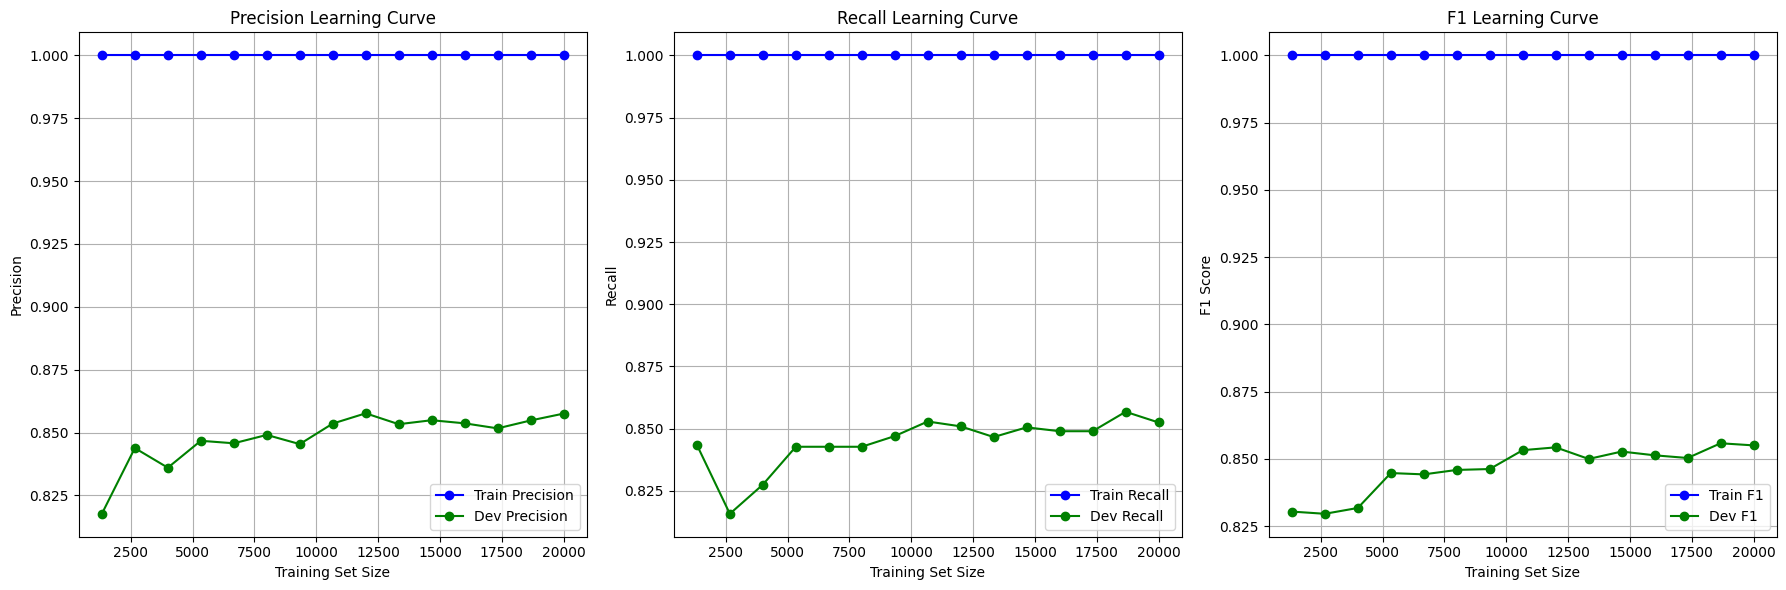

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def RandomForest_learning_curves(x_train, y_train, x_val, y_val, x_test, y_test, n_splits):
    split_size = int(len(x_train) / n_splits)
    x_splits = np.split(x_train[:n_splits*split_size], n_splits)
    y_splits = np.split(y_train[:n_splits*split_size], n_splits)

    train_p, val_p = [], []
    train_r, val_r = [], []
    train_f1, val_f1 = [], []

    curr_x = x_splits[0]
    curr_y = y_splits[0]

    def get_metrics(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        return precision, recall, f1

    def evaluate_step(model, x, y, p_list, r_list, f1_list):
        preds = model.predict(x)
        p, r, f = get_metrics(y, preds)
        p_list.append(p)
        r_list.append(r)
        f1_list.append(f)

    clf = RandomForestClassifier(criterion='entropy', random_state=42)
    clf.fit(curr_x, curr_y)

    evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
    evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    for i in range(1, len(x_splits)):
        curr_x = np.concatenate((curr_x, x_splits[i]), axis=0)
        curr_y = np.concatenate((curr_y, y_splits[i]), axis=0)

        clf = RandomForestClassifier(criterion='entropy', random_state=42)
        clf.fit(curr_x, curr_y)

        evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
        evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    steps = list(range(split_size, len(curr_x) + 1, split_size))
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(steps, train_p, 'o-', color="b", label="Train Precision")
    plt.plot(steps, val_p, 'o-', color="green", label="Dev Precision")
    plt.title("Precision Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(steps, train_r, 'o-', color="b", label="Train Recall")
    plt.plot(steps, val_r, 'o-', color="green", label="Dev Recall")
    plt.title("Recall Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(steps, train_f1, 'o-', color="b", label="Train F1")
    plt.plot(steps, val_f1, 'o-', color="green", label="Dev F1")
    plt.title("F1 Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

RandomForest_learning_curves(x_train_sub, y_train_sub, x_dev, y_dev, x_test_final, y_test, n_splits=15)

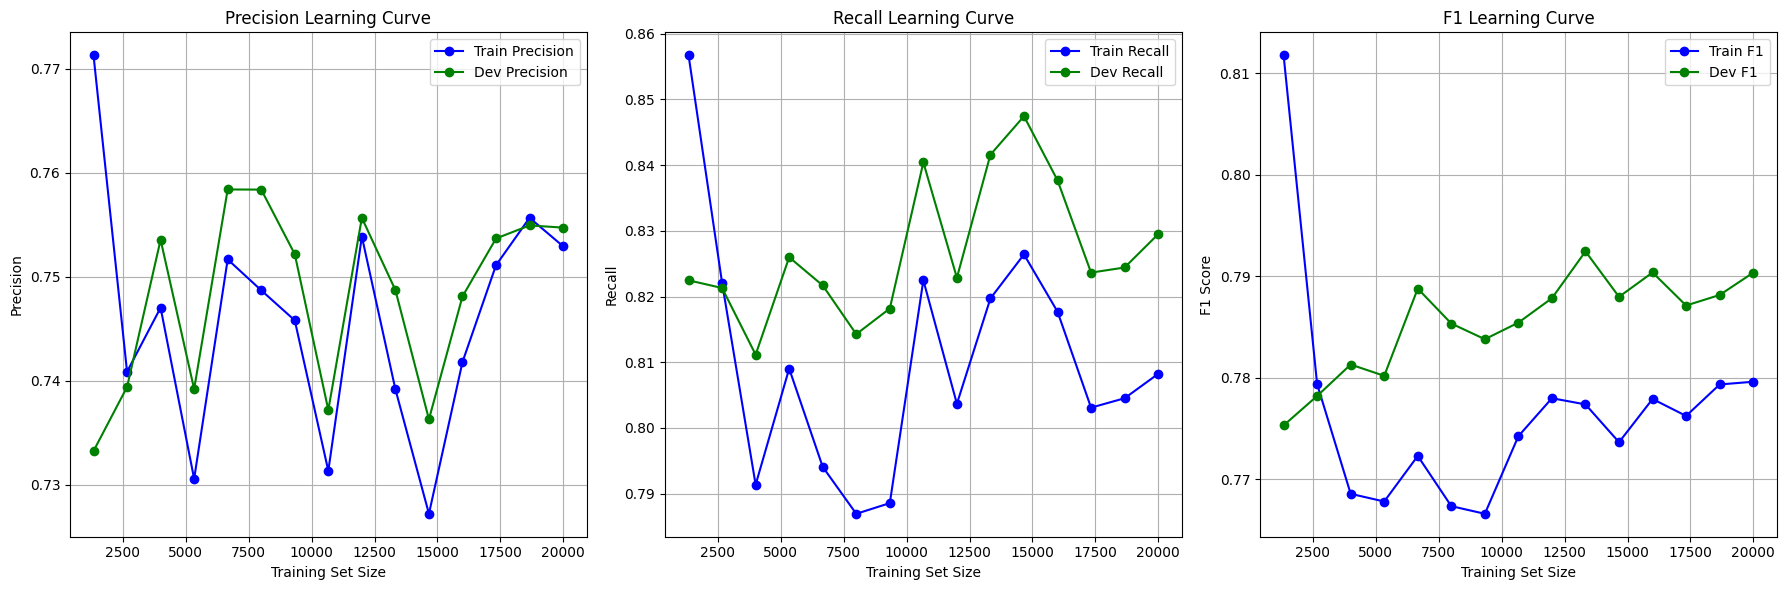

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier

def AdaBoost_learning_curves(x_train, y_train, x_val, y_val, x_test, y_test, n_splits):
    split_size = int(len(x_train) / n_splits)
    x_splits = np.split(x_train[:n_splits*split_size], n_splits)
    y_splits = np.split(y_train[:n_splits*split_size], n_splits)

    train_p, val_p = [], []
    train_r, val_r = [], []
    train_f1, val_f1 = [], []

    curr_x = x_splits[0]
    curr_y = y_splits[0]

    def get_metrics(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        return precision, recall, f1

    def evaluate_step(model, x, y, p_list, r_list, f1_list):
        preds = model.predict(x)
        p, r, f = get_metrics(y, preds)
        p_list.append(p)
        r_list.append(r)
        f1_list.append(f)

    clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=60,
    random_state=1)
    clf.fit(curr_x, curr_y)

    evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
    evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    for i in range(1, len(x_splits)):
        curr_x = np.concatenate((curr_x, x_splits[i]), axis=0)
        curr_y = np.concatenate((curr_y, y_splits[i]), axis=0)

        clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                n_estimators=60,
                random_state=1)
        clf.fit(curr_x, curr_y)

        evaluate_step(clf, curr_x, curr_y, train_p, train_r, train_f1)
        evaluate_step(clf, x_val, y_val, val_p, val_r, val_f1)

    steps = list(range(split_size, len(curr_x) + 1, split_size))
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(steps, train_p, 'o-', color="b", label="Train Precision")
    plt.plot(steps, val_p, 'o-', color="green", label="Dev Precision")
    plt.title("Precision Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(steps, train_r, 'o-', color="b", label="Train Recall")
    plt.plot(steps, val_r, 'o-', color="green", label="Dev Recall")
    plt.title("Recall Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(steps, train_f1, 'o-', color="b", label="Train F1")
    plt.plot(steps, val_f1, 'o-', color="green", label="Dev F1")
    plt.title("F1 Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

AdaBoost_learning_curves(x_train_sub, y_train_sub, x_dev, y_dev, x_test_final, y_test, n_splits=15)